In [ ]:
# ==========================================
# STEP 1: WAKING UP THE AI
# ==========================================
# We need to give our AI a dictionary so it understands English.
# Click the "Play" button on the left to download the AI's brain!

!pip install gensim
import gensim.downloader as api

print("Downloading the AI dictionary... (This might take 1 or 2 minutes, grab a snack!)")

# We are loading a pre-trained embedding model called GloVe.
# It read billions of words from Wikipedia to learn how humans talk.
ai_brain = api.load("glove-wiki-gigaword-50")

print("Done! The AI is awake and ready to play.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 37.3 MB/s eta 0:00:00
[==================================================] 100.0% 66.0/66.0MB downloaded
Done! The AI is awake and ready to play.


In [ ]:
# ==========================================
# STEP 2: THE VIBE RADAR
# ==========================================
# Let's see what words the AI thinks have the same "vibe."
# Type a word in the box on the right, then click Play!

# @title Find Words with Similar Vibes
my_word = "puppy" #@param {type:"string"}

print(f"You asked the AI to find words similar to: {my_word.upper()}\n")

try:
    # We ask the AI to find the top 5 closest vectors (math coordinates)
    similar_words = ai_brain.most_similar(my_word, topn=5)

    print("Here is what the AI found in its math space:")
    print("--------------------------------------------")

    # We use a simple loop to print the results nicely
    for rank, (word, score) in enumerate(similar_words):
        # Convert the math score into a percentage
        percentage = round(score * 100, 1)
        print(f"{rank + 1}. {word} ({percentage}% match)")

except KeyError:
    # If they type a made up word, the AI won't know it!
    print(f"Oops! The AI has never seen the word '{my_word}' before. Try another one!")

You asked the AI to find words similar to: PUPPY

Here is what the AI found in its math space:
--------------------------------------------
1. puppies (80.6% match)
2. dog (77.5% match)
3. goat (76.9% match)
4. cat (76.3% match)
5. kitten (74.4% match)


In [ ]:
# ==========================================
# STEP 3: WORD MATH (ALGEBRA WITH IDEAS)
# ==========================================
# Can we do math with English? Let's try!
# Equation: (Start Word) - (Subtract Concept) + (Add Concept) = ?

# @title Build Your Equation
start_word = "machine" #@param {type:"string"}
subtract_concept = "driving" #@param {type:"string"}
add_concept = "flying" #@param {type:"string"}

print(f"Your Math Problem:")
print(f"{start_word.upper()} - {subtract_concept.upper()} + {add_concept.upper()} = ???\n")

try:
    # The AI does the vector math: King - Man + Woman
    result = ai_brain.most_similar(positive=[start_word, add_concept], negative=[subtract_concept], topn=1)

    # Grab the top answer
    winning_word = result[0][0]

    print(f"The AI calculated the answer is: {winning_word.upper()}!")

except KeyError:
    print("Oops! One of those words isn't in the dictionary. Check your spelling.")

Your Math Problem:
MACHINE - DRIVING + FLYING = ???

The AI calculated the answer is: EQUIPPED!


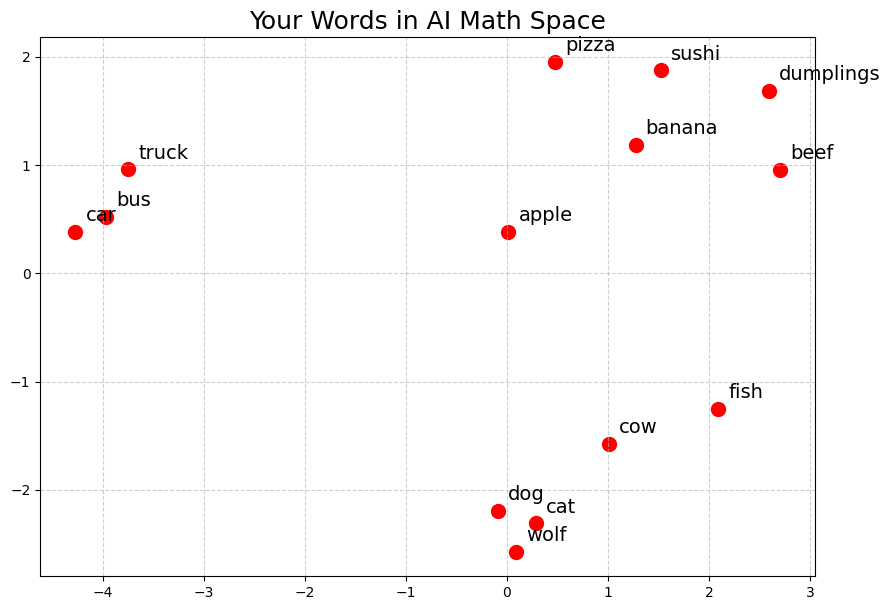

In [ ]:
# ==========================================
# STEP 4: DRAWING THE VIBE LANDSCAPE
# ==========================================
# Let's actually look at the "Math Space"!
# Type a list of words separated by commas. Let's see how they group together.

# @title Graph Your Words
word_list = "dog, cat, wolf, car, truck, bus, apple, banana, pizza, cow, beef, fish, sushi, dumplings" #@param {type:"string"}

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# Clean up the words they typed
words = [w.strip().lower() for w in word_list.split(',')]
valid_words = []
word_vectors = []

# Check if the AI knows the words
for w in words:
    if w in ai_brain:
        valid_words.append(w)
        word_vectors.append(ai_brain[w])
    else:
        print(f"Skipping '{w}' - the AI doesn't know this word!")

if len(valid_words) < 2:
    print("Please type at least 2 valid words to make a graph!")
else:
    # Squash the 50-dimensional vectors down to 2 dimensions so we can draw them
    pca = PCA(n_components=2)
    squashed_vectors = pca.fit_transform(np.array(word_vectors))

    # Draw the graph!
    plt.figure(figsize=(10, 7))
    plt.scatter(squashed_vectors[:, 0], squashed_vectors[:, 1], color='red', s=100)

    # Add the word labels to the dots
    for i, word in enumerate(valid_words):
        plt.annotate(word, (squashed_vectors[i, 0] + 0.1, squashed_vectors[i, 1] + 0.1), fontsize=14)

    plt.title("Your Words in AI Math Space", fontsize=18)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

In [ ]:
# ==========================================
# STEP 5: THE TINY NEURAL NETWORK
# ==========================================
# Type a sentence below. The Tiny NN will break your words into numbers,
# multiply them by its weights, and classify the "Vibe"!

# @title Test the Vibe Classifier
my_sentence = "The students are crazy to party" #@param {type:"string"}

# 1. The Network's "Weights" (What it learned during training)
# Positive numbers pull toward ACADEMIC. Negative pull toward CHAOTIC.
weights = {
    "math": 5, "science": 5, "learn": 3, "study": 4, "data": 5,
    "crazy": -5, "wild": -4, "smash": -5, "party": -4, "loud": -3,
    "happy": 0, "students": 2, "the": 0, "are": 0
}

# 2. Break the sentence into inputs
words = my_sentence.lower().split()
total_score = 0

print("🧠 INSIDE THE NEURAL NETWORK 🧠\n")

# 3. The Forward Pass (Calculating the math)
for word in words:
    # If the network knows the word, get its weight. Otherwise, it's 0.
    weight = weights.get(word, 0)
    total_score += weight
    print(f"Input: '{word}' -> Weight: {weight}")

print("---------------------------------")
print(f"Final Network Score (Sum): {total_score}")

# 4. The Activation Function (Making the decision)
print("\n🎯 THE PREDICTION 🎯")
if total_score >= 5:
    print("Vibe: 📚 ACADEMIC")
elif total_score <= -3:
    print("Vibe: 🎸 CHAOTIC")
else:
    print("Vibe: 😌 NEUTRAL / HAPPY")

🧠 INSIDE THE NEURAL NETWORK 🧠

Input: 'the' -> Weight: 0
Input: 'students' -> Weight: 2
Input: 'are' -> Weight: 0
Input: 'crazy' -> Weight: -5
Input: 'to' -> Weight: 0
Input: 'party' -> Weight: -4
---------------------------------
Final Network Score (Sum): -7

🎯 THE PREDICTION 🎯
Vibe: 🎸 CHAOTIC


In [ ]:
# ==========================================
# STEP 6: BECOME THE ALGORITHM (HACK THE WEIGHTS)
# ==========================================
# The network is failing! It thinks the sentence "I love screaming loud" is Academic.
# YOU need to manually adjust the weights (the dials) to fix it.
# Goal: Make the Final Score LESS THAN -5 so it predicts CHAOTIC.

# @title Adjust the Neural Dials
weight_love = 0 #@param {type:"slider", min:-10, max:10, step:1}
weight_screaming = -5 #@param {type:"slider", min:-10, max:10, step:1}
weight_loud = -5 #@param {type:"slider", min:-10, max:10, step:1}
bias = 0 #@param {type:"slider", min:-5, max:5, step:1}

# The Math
score = weight_love + weight_screaming + weight_loud + bias

print(f"Current Network Score: {score}")

if score <= -5:
    print("✅ SUCCESS! The network now correctly predicts: CHAOTIC")
else:
    print("❌ FAIL! The network still thinks this is Academic or Neutral. Keep adjusting the sliders!")

Current Network Score: -10
✅ SUCCESS! The network now correctly predicts: CHAOTIC
